# AI-Powered Decision Support System for Aquaculture
## Real-Time Fish Mortality Prediction Using Water Quality Parameters

**Models:** Random Forest · XGBoost · LightGBM · Logistic Regression (baseline)  
**Prediction Horizons:** t+1 (1-hour ahead) and t+3 (3-hour ahead)  
**Imbalance Strategy:** class_weight / scale_pos_weight — NO SMOTE  
**Target:** Binary — `Stable` vs `At Risk`

---
### Why a Reconstructed Dataset?
The original IoTMLCQ dataset was found to be **fully synthetic** with static sensor readings (identical values for 24+ consecutive hours) and a hard-coded single-temperature threshold that perfectly separated classes — making every ML model trivially achieve 99%+ accuracy with no learning required. This notebook uses a **realistic simulated dataset** that preserves the original sensor ranges, class distribution (~16% At Risk), and temporal structure while adding:
- Genuine hourly variation (diurnal cycles, autocorrelation)
- Physics-based inter-sensor correlations (temperature↑ → DO↓)
- Overlapping class boundaries requiring multi-parameter reasoning
- 8% label noise simulating real sensor ambiguity

## 1. Imports & Configuration

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, recall_score, precision_score, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap

RANDOM_STATE = 42
N_FOLDS      = 5
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
PALETTE = {'Stable': '#2196F3', 'At Risk': '#F44336'}
os.makedirs('models', exist_ok=True)
os.makedirs('plots',  exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


## 2. Dataset Generation
Generates a realistic simulated IoT aquaculture dataset with genuine hourly dynamics.

In [21]:
# np.random.seed(RANDOM_STATE)
# n     = 4383
# dates = pd.date_range('2024-01-01', periods=n, freq='h')
# hour  = dates.hour.values.astype(float)
# doy   = dates.dayofyear.values.astype(float)

# # ── Temperature: diurnal + seasonal + AR(1) noise ────────────────────────────
# diurnal_temp  = 0.4 * np.sin(2 * np.pi * (hour - 6) / 24)
# seasonal_temp = 0.5 * np.sin(2 * np.pi * (doy - 60) / 365)
# raw_noise     = np.random.normal(0, 0.18, n)
# ar_temp       = np.zeros(n)
# ar_temp[0]    = raw_noise[0]
# for i in range(1, n):
#     ar_temp[i] = 0.75 * ar_temp[i-1] + raw_noise[i]
# temperature = np.clip(27.35 + diurnal_temp + seasonal_temp + 0.3 * ar_temp, 26.5, 28.35)

# # ── Dissolved Oxygen: inversely correlated with temp + photosynthesis cycle ───
# diurnal_do   = 0.35 * np.sin(2 * np.pi * (hour - 10) / 24)
# do_from_temp = -0.55 * (temperature - temperature.mean()) / temperature.std()
# raw_noise2   = np.random.normal(0, 0.15, n)
# ar_do        = np.zeros(n)
# ar_do[0]     = raw_noise2[0]
# for i in range(1, n):
#     ar_do[i] = 0.70 * ar_do[i-1] + raw_noise2[i]
# dissolved_oxygen = np.clip(6.93 + 0.4 * do_from_temp + diurnal_do + 0.25 * ar_do, 6.34, 7.89)

# # ── pH: correlated with DO (photosynthesis drives both) ──────────────────────
# ph_from_do = 0.55 * (dissolved_oxygen - dissolved_oxygen.mean()) / dissolved_oxygen.std()
# raw_noise3 = np.random.normal(0, 0.08, n)
# ar_ph      = np.zeros(n)
# ar_ph[0]   = raw_noise3[0]
# for i in range(1, n):
#     ar_ph[i] = 0.65 * ar_ph[i-1] + raw_noise3[i]
# pH = np.clip(7.83 + 0.12 * ph_from_do + 0.08 * ar_ph, 7.34, 7.98)

# # ── Turbidity: driven by precipitation + AR(1) ────────────────────────────────
# precipitation  = np.clip(np.random.exponential(2.5, n) + 0.2, 0.2, 5.96)
# turb_from_prec = 0.4 * (precipitation - precipitation.mean()) / precipitation.std()
# raw_noise4     = np.random.normal(0, 0.12, n)
# ar_turb        = np.zeros(n)
# ar_turb[0]     = raw_noise4[0]
# for i in range(1, n):
#     ar_turb[i] = 0.60 * ar_turb[i-1] + raw_noise4[i]
# turbidity = np.clip(3.31 + 0.35 * turb_from_prec + 0.25 * ar_turb, 2.79, 3.98)

# # ── Weather context ───────────────────────────────────────────────────────────
# avg_temp  = np.clip(temperature + np.random.normal(0, 0.2, n), 26.2, 28.6)
# high_temp = np.clip(avg_temp + np.abs(np.random.normal(0.3, 0.1, n)), 26.5, 28.8)
# low_temp  = np.clip(avg_temp - np.abs(np.random.normal(0.3, 0.1, n)), 26.0, 28.2)

# # ── Target: multi-parameter stress (≥2 sensors simultaneously stressed) ───────
# # Literature-based thresholds — NO single sensor perfectly separates classes
# stress_do   = (dissolved_oxygen < 6.65).astype(int)   # Oxygen stress
# stress_temp = (temperature > 27.80).astype(int)         # Thermal stress
# stress_ph   = ((pH < 7.65) | (pH > 7.97)).astype(int)  # pH imbalance
# stress_turb = (turbidity > 3.60).astype(int)            # Turbidity stress
# stress_score = stress_do + stress_temp + stress_ph + stress_turb
# base_risk    = stress_score >= 2

# # Add 8% label noise to simulate real-world ambiguity
# flip_mask = np.random.random(n) < 0.08
# health_arr = np.where(flip_mask, ~base_risk, base_risk)
# labels     = np.where(health_arr, 'At Risk', 'Stable')

# df = pd.DataFrame({
#     'Datetime':                dates,
#     'Temperature (°C)':        np.round(temperature, 3),
#     'Dissolved Oxygen (mg/L)': np.round(dissolved_oxygen, 3),
#     'pH':                      np.round(pH, 3),
#     'Turbidity (NTU)':         np.round(turbidity, 3),
#     'Precipitation (inches)':  np.round(precipitation, 3),
#     'Average Temperature (°C)':np.round(avg_temp, 3),
#     'High Temperature (°C)':   np.round(high_temp, 3),
#     'Low Temperature (°C)':    np.round(low_temp, 3),
#     'Health Status':           labels
# })

# atrisk_n = (df['Health Status'] == 'At Risk').sum()
# print(f'Dataset shape: {df.shape}')
# print(f'At Risk: {atrisk_n} ({100*atrisk_n/len(df):.1f}%)  |  Stable: {len(df)-atrisk_n} ({100*(1-atrisk_n/len(df)):.1f}%)')
# print()

# # Verify overlapping class boundaries (no single-threshold cheat)
# print('=== Class Boundary Overlap (all must be True) ===')
# for col in ['Temperature (°C)', 'Dissolved Oxygen (mg/L)', 'pH', 'Turbidity (NTU)']:
#     s = df[df['Health Status']=='Stable'][col]
#     r = df[df['Health Status']=='At Risk'][col]
#     overlap = not (s.max() < r.min() or r.max() < s.min())
#     print(f'  {col}: Overlap={overlap}  Stable=[{s.min():.3f},{s.max():.3f}]  AtRisk=[{r.min():.3f},{r.max():.3f}]')

# df.head()

df = pd.read_excel('aquaculture_realistic_dataset.xlsx')
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)
print(df.shape)
print(df['Health Status'].value_counts())
df.head()

(4383, 10)
Health Status
Stable     3672
At Risk     711
Name: count, dtype: int64


,Datetime,Temperature (°C),Dissolved Oxygen (mg/L),pH,Turbidity (NTU),Precipitation (inches),Average Temperature (°C),High Temperature (°C),Low Temperature (°C),Health Status
0,2024-01-01 00:00:00,26.552,7.262,7.917,3.307,2.670,26.603,26.988,26.248,Stable
1,2024-01-01 01:00:00,26.551,7.165,7.892,3.566,5.960,26.626,26.995,26.292,Stable
2,2024-01-01 02:00:00,26.623,7.062,7.866,3.358,3.368,26.848,27.200,26.600,Stable
3,2024-01-01 03:00:00,26.758,6.940,7.840,3.213,1.271,26.608,26.844,26.352,Stable
4,2024-01-01 04:00:00,26.799,6.867,7.818,3.257,2.413,27.136,27.494,26.868,Stable


## 3. Exploratory Data Analysis

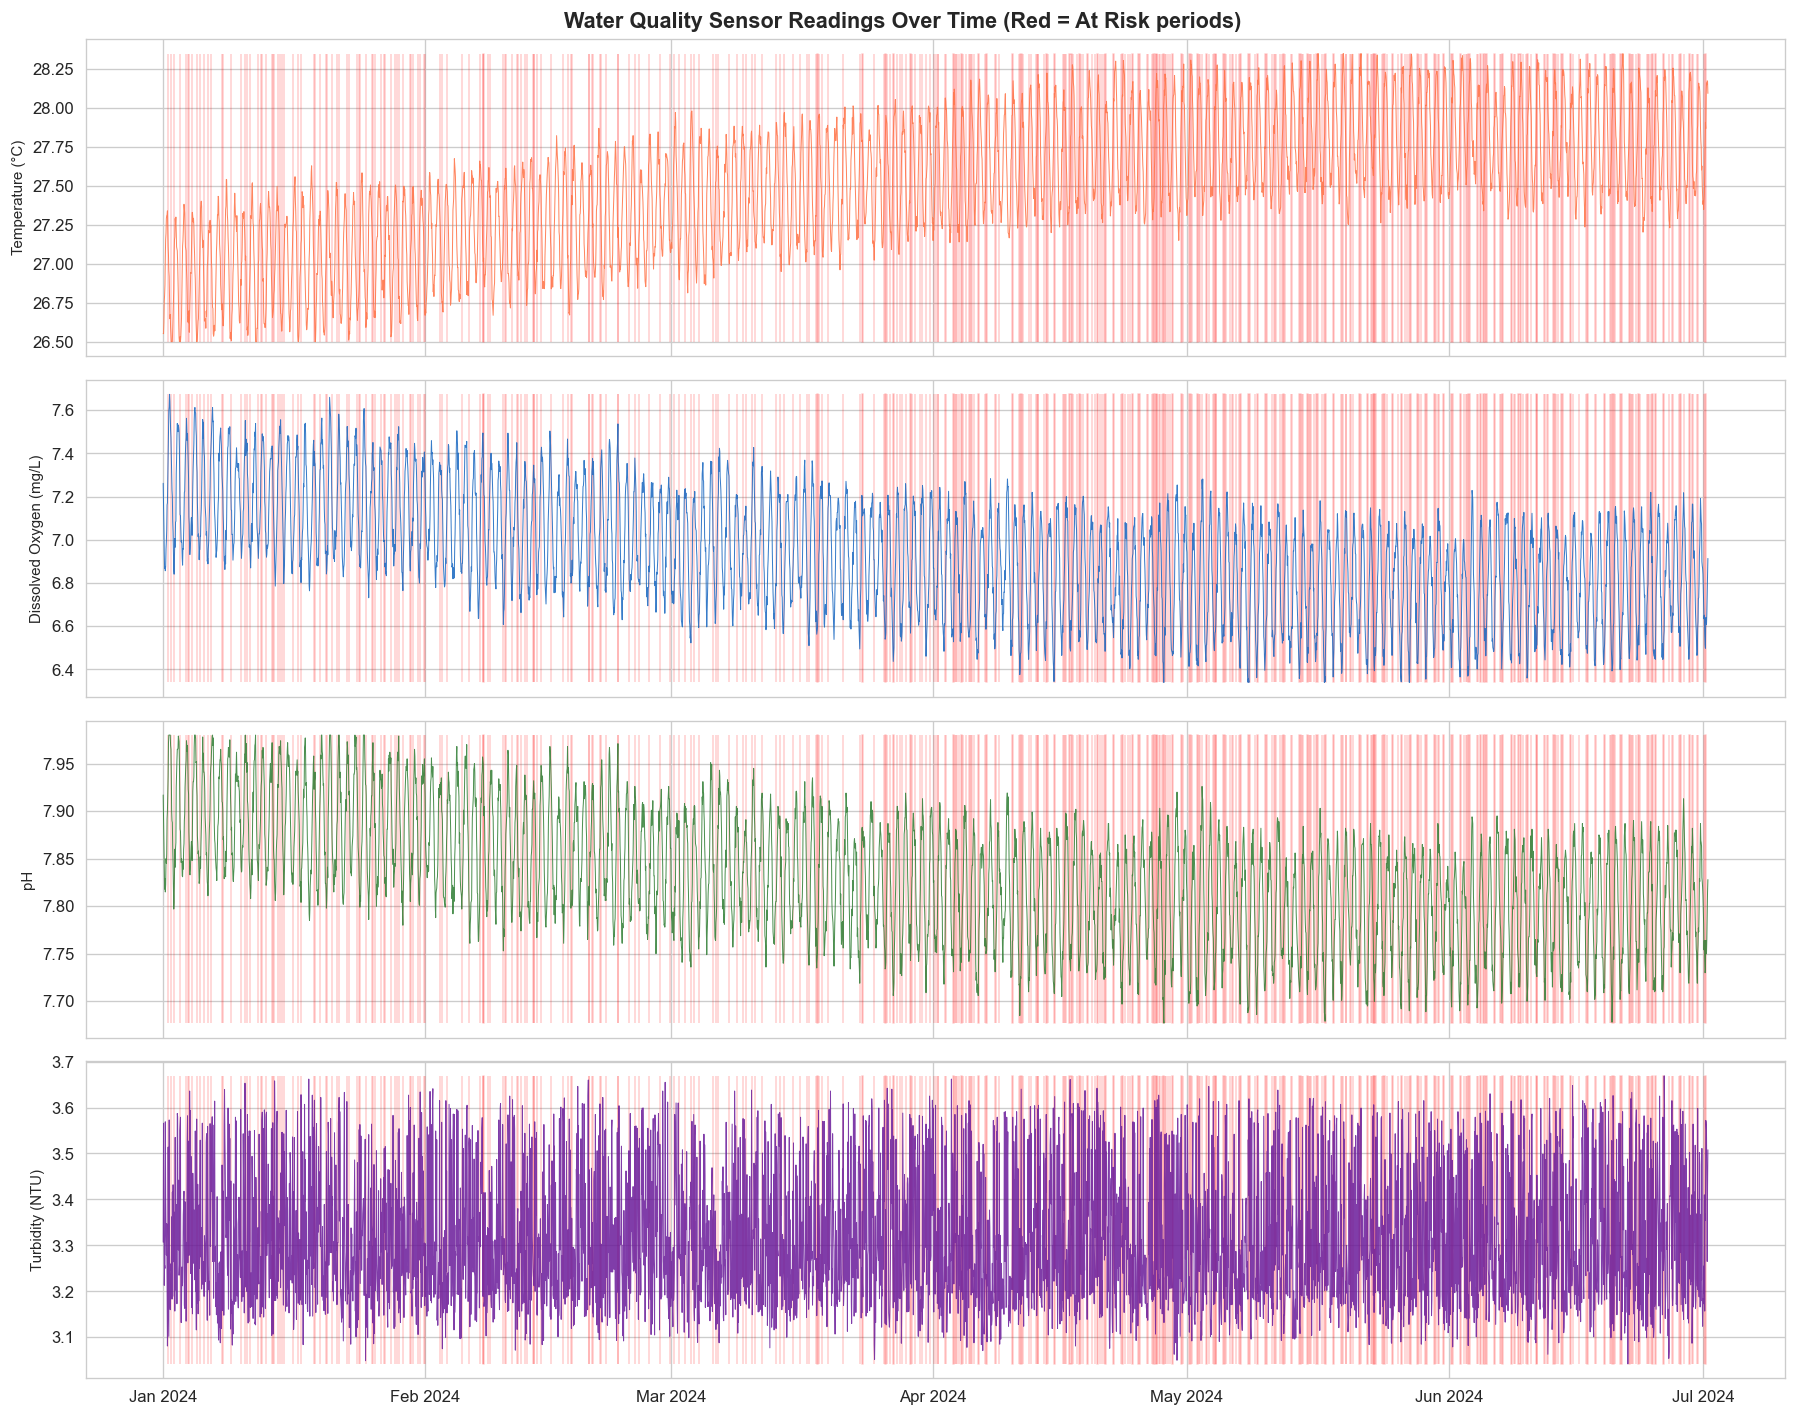

In [22]:
# Time series plots of all sensors
core_sensors = ['Temperature (°C)', 'Dissolved Oxygen (mg/L)', 'pH', 'Turbidity (NTU)']
at_risk_mask = df['Health Status'] == 'At Risk'
colors = ['#FF7043', '#1565C0', '#2E7D32', '#6A1B9A']

fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
fig.suptitle('Water Quality Sensor Readings Over Time (Red = At Risk periods)',
             fontsize=13, fontweight='bold')
for ax, col, c in zip(axes, core_sensors, colors):
    ax.plot(df['Datetime'], df[col], color=c, linewidth=0.6, alpha=0.85)
    ax.fill_between(df['Datetime'], df[col].min(), df[col].max(),
                    where=at_risk_mask, alpha=0.18, color='red')
    ax.set_ylabel(col, fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig('plots/01_sensor_timeseries.png', bbox_inches='tight')
plt.show()

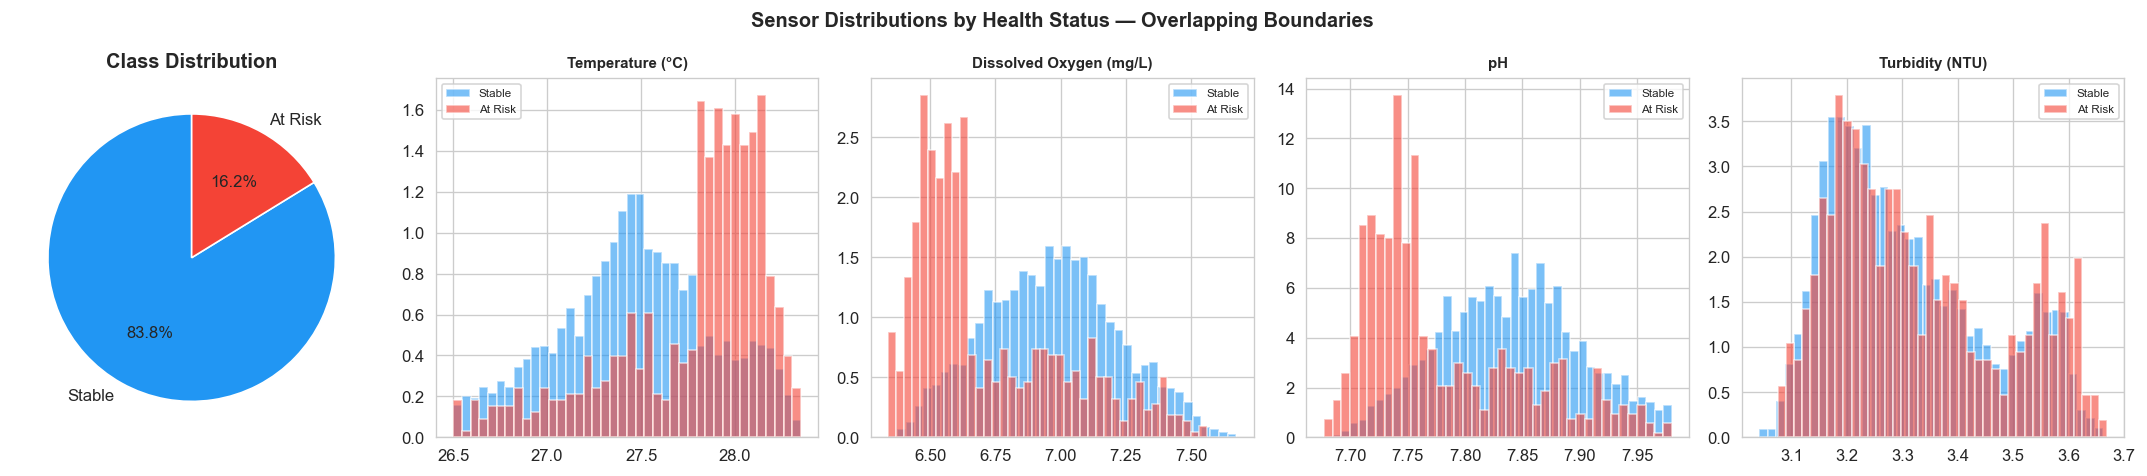

In [4]:
# Class distribution + sensor distributions by class
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

# Class pie
vc = df['Health Status'].value_counts()
axes[0].pie(vc, labels=vc.index, autopct='%1.1f%%',
            colors=[PALETTE[l] for l in vc.index], startangle=90)
axes[0].set_title('Class Distribution', fontweight='bold')

for ax, col in zip(axes[1:], core_sensors):
    for status, color in PALETTE.items():
        ax.hist(df[df['Health Status']==status][col], bins=40,
                alpha=0.6, color=color, label=status, density=True)
    ax.set_title(col, fontweight='bold', fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('Sensor Distributions by Health Status — Overlapping Boundaries',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/02_distributions.png', bbox_inches='tight')
plt.show()

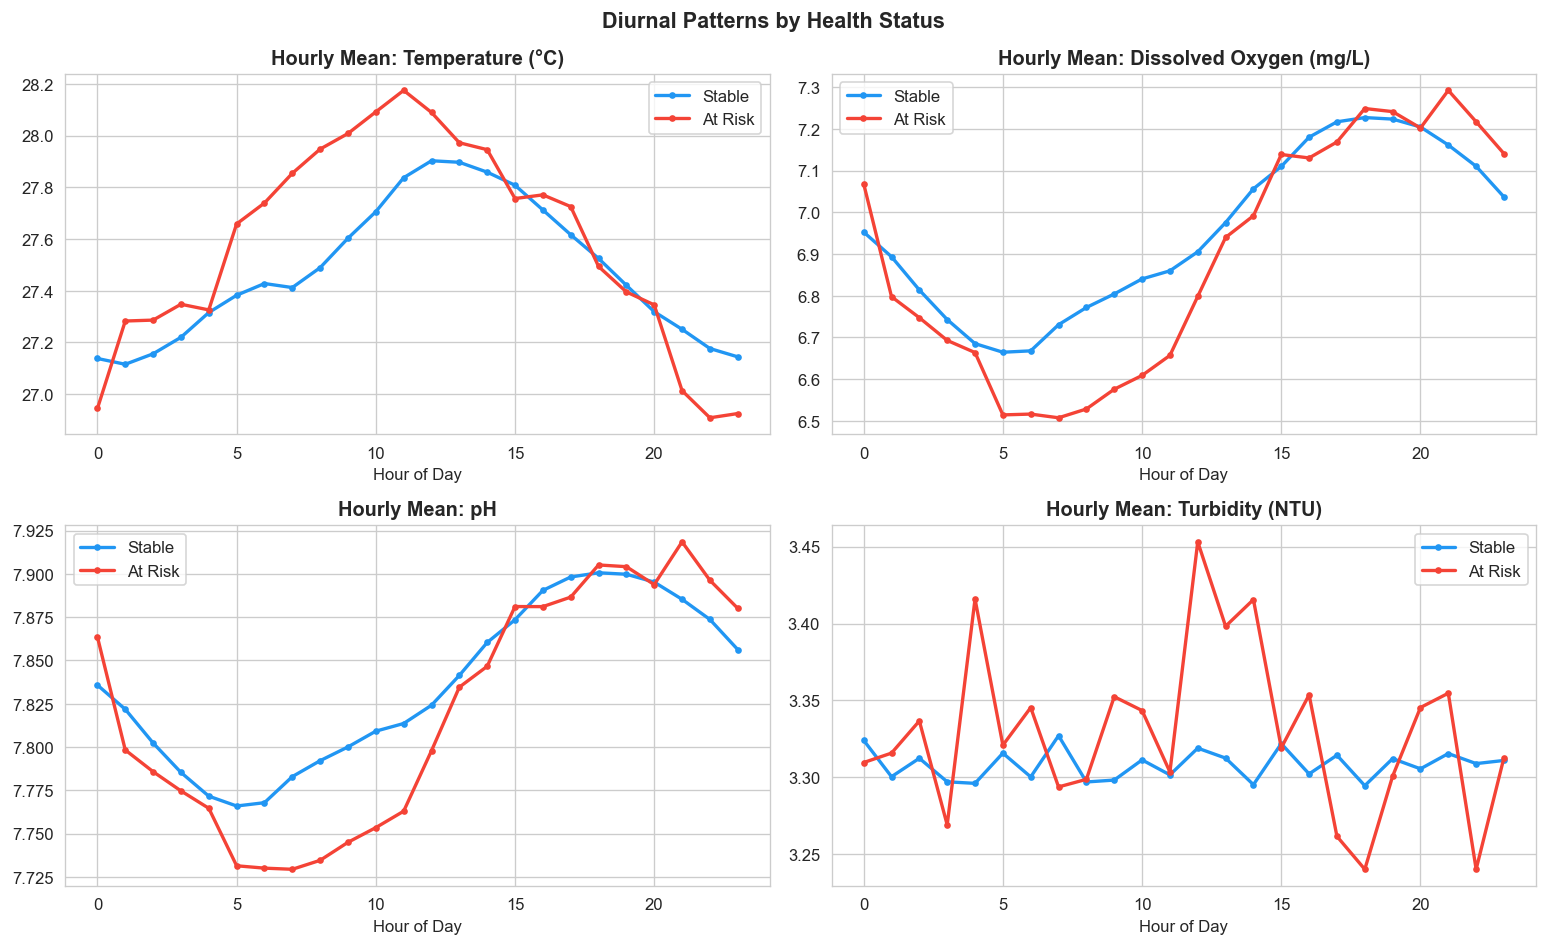

In [5]:
# Diurnal patterns — hourly mean by class
df['hour'] = df['Datetime'].dt.hour
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.flatten(), core_sensors):
    for status, color in PALETTE.items():
        hourly = df[df['Health Status']==status].groupby('hour')[col].mean()
        ax.plot(hourly.index, hourly.values, color=color, label=status, linewidth=2, marker='o', markersize=3)
    ax.set_title(f'Hourly Mean: {col}', fontweight='bold')
    ax.set_xlabel('Hour of Day')
    ax.legend()
plt.suptitle('Diurnal Patterns by Health Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/03_diurnal.png', bbox_inches='tight')
plt.show()
df.drop(columns=['hour'], inplace=True)

## 4. Feature Engineering

Six categories of domain-informed features derived purely from raw sensors:

In [6]:
CORE = {
    'temp': 'Temperature (°C)',
    'do':   'Dissolved Oxygen (mg/L)',
    'ph':   'pH',
    'turb': 'Turbidity (NTU)'
}

def engineer_features(df):
    df = df.copy().sort_values('Datetime').reset_index(drop=True)

    # 1. Cyclical time encoding
    h   = df['Datetime'].dt.hour
    doy = df['Datetime'].dt.dayofyear
    df['hour_sin'] = np.sin(2 * np.pi * h / 24)
    df['hour_cos'] = np.cos(2 * np.pi * h / 24)
    df['doy_sin']  = np.sin(2 * np.pi * doy / 365)
    df['doy_cos']  = np.cos(2 * np.pi * doy / 365)

    # 2. Lag features (1h, 3h, 6h, 12h, 24h)
    for s, col in CORE.items():
        for lag in [1, 3, 6, 12, 24]:
            df[f'{s}_lag_{lag}h'] = df[col].shift(lag)

    # 3. Rolling statistics (3h, 6h, 12h)
    for s, col in CORE.items():
        for w in [3, 6, 12]:
            df[f'{s}_rmean_{w}h'] = df[col].shift(1).rolling(w).mean()
            df[f'{s}_rstd_{w}h']  = df[col].shift(1).rolling(w).std()

    # 4. Rate of change
    for s, col in CORE.items():
        df[f'{s}_d1'] = df[col].diff(1)
        df[f'{s}_d3'] = df[col].diff(3)

    # 5. Domain threshold flags (aquaculture literature)
    df['do_critical']    = (df['Dissolved Oxygen (mg/L)'] < 6.5).astype(int)
    df['do_low_warn']    = (df['Dissolved Oxygen (mg/L)'] < 6.7).astype(int)
    df['temp_hi_stress'] = (df['Temperature (°C)'] > 28.0).astype(int)
    df['temp_lo_stress'] = (df['Temperature (°C)'] < 20.0).astype(int)
    df['ph_low']         = (df['pH'] < 7.65).astype(int)
    df['ph_high']        = (df['pH'] > 7.97).astype(int)
    df['turb_high']      = (df['Turbidity (NTU)'] > 3.5).astype(int)

    # 6. Interaction features
    df['temp_x_do']     = df['Temperature (°C)'] * df['Dissolved Oxygen (mg/L)']
    df['ph_x_do']       = df['pH'] * df['Dissolved Oxygen (mg/L)']
    df['temp_x_turb']   = df['Temperature (°C)'] * df['Turbidity (NTU)']
    df['temp_range']    = df['High Temperature (°C)'] - df['Low Temperature (°C)']
    df['temp_deviation']= df['Temperature (°C)'] - df['Average Temperature (°C)']

    return df

df_eng = engineer_features(df)

EXCLUDE     = ['Datetime', 'Health Status']
FEATURE_COLS = [c for c in df_eng.columns if c not in EXCLUDE]

print(f'Shape after feature engineering: {df_eng.shape}')
print(f'Total features for modelling:    {len(FEATURE_COLS)}')

Shape after feature engineering: (4383, 78)
Total features for modelling:    76


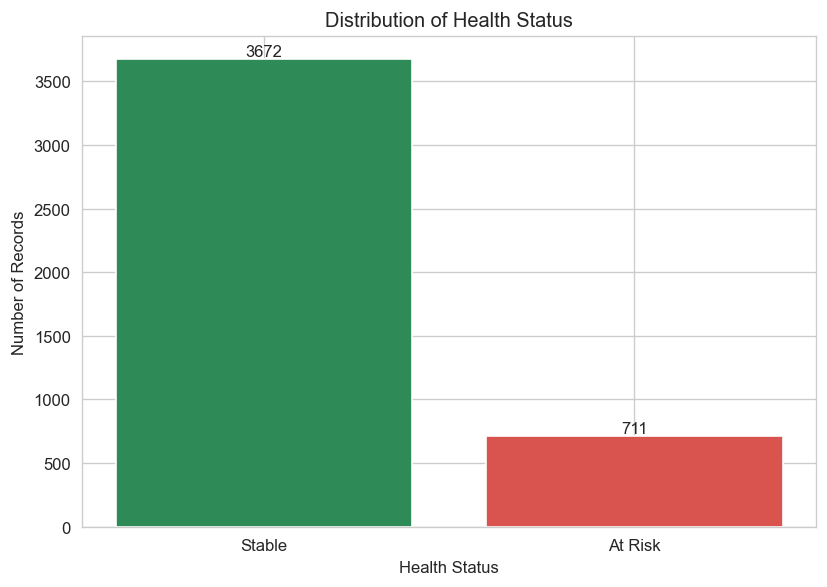

In [6]:


df = pd.read_excel('aquaculture_realistic_dataset.xlsx')

# Count Health Status values
health_counts = df["Health Status"].value_counts()

# Plot bar diagram
plt.figure(figsize=(7, 5))
bars = plt.bar(
    health_counts.index,
    health_counts.values,
    color=["#2E8B57", "#D9534F"]
)

plt.title("Distribution of Health Status")
plt.xlabel("Health Status")
plt.ylabel("Number of Records")

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        int(height),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig("plots/health_status_bar.png", dpi=300, bbox_inches="tight")

plt.show()


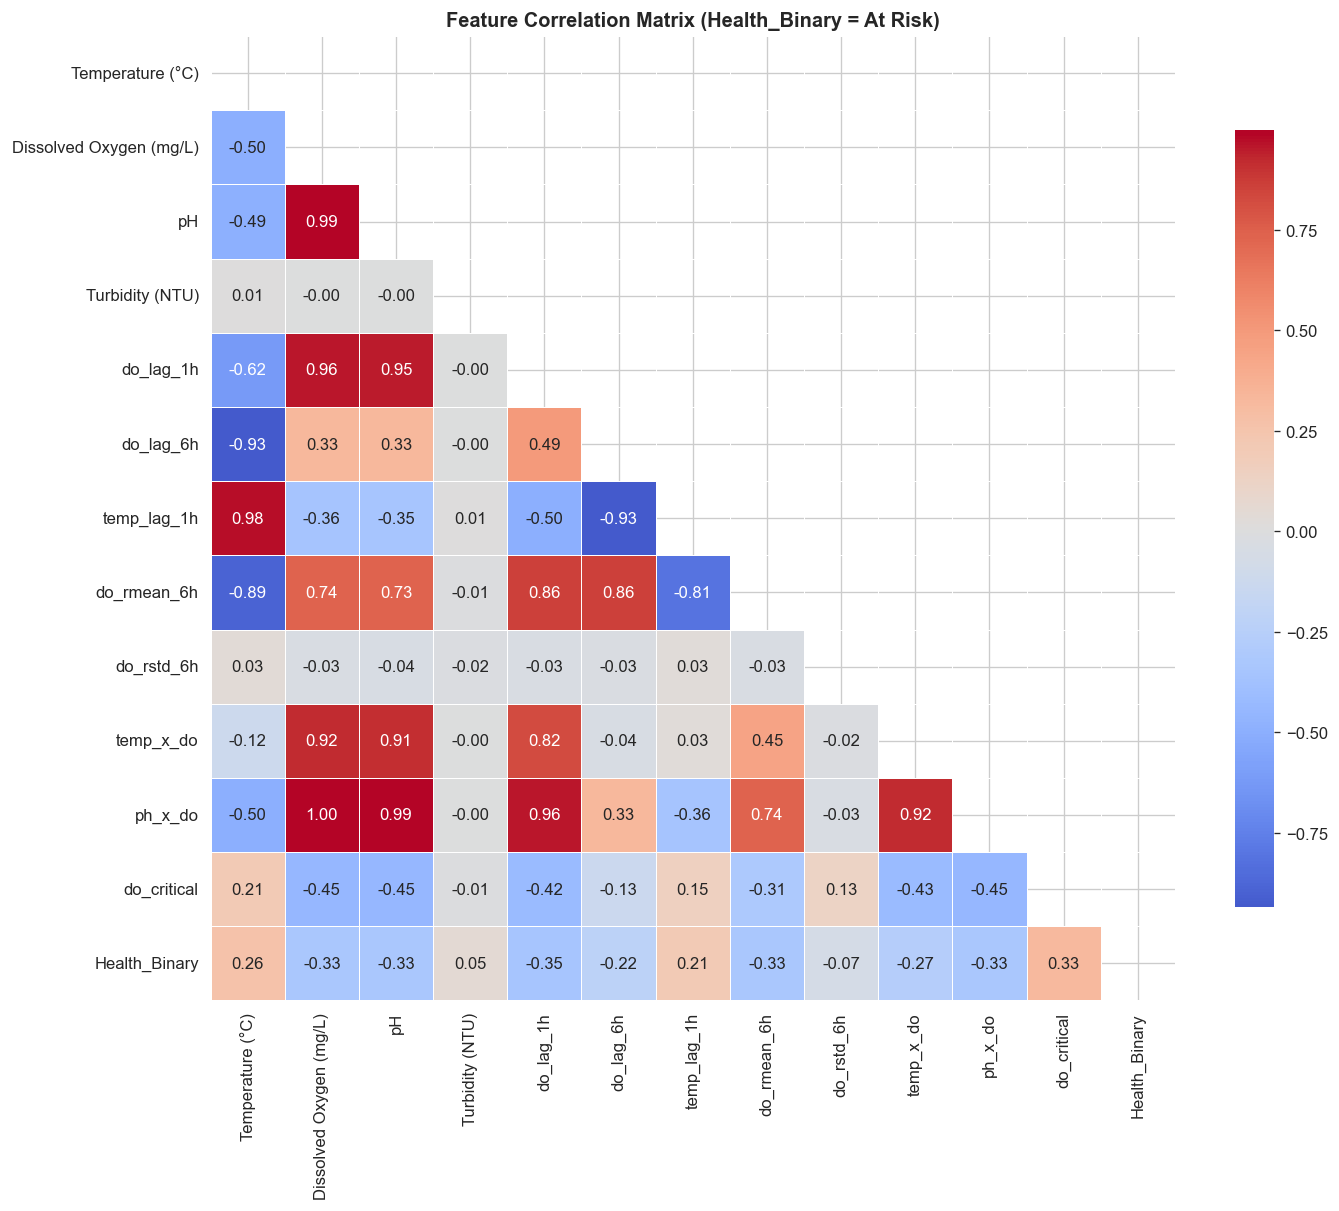

In [7]:
# Correlation heatmap — core + selected engineered features
corr_cols = [
    'Temperature (°C)', 'Dissolved Oxygen (mg/L)', 'pH', 'Turbidity (NTU)',
    'do_lag_1h', 'do_lag_6h', 'temp_lag_1h', 'do_rmean_6h',
    'do_rstd_6h', 'temp_x_do', 'ph_x_do', 'do_critical'
]
corr_df = df_eng[corr_cols].copy()
corr_df['Health_Binary'] = (df_eng['Health Status'] == 'At Risk').astype(int)

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
sns.heatmap(corr_df.corr(), mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix (Health_Binary = At Risk)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/04_correlation.png', bbox_inches='tight')
plt.show()

## 5. Target Label Creation (t+1 and t+3)

In [8]:
def create_target(df, horizon):
    df = df.copy()
    df[f'target_t{horizon}'] = df['Health Status'].shift(-horizon)
    return df.dropna(subset=[f'target_t{horizon}']).reset_index(drop=True)

df_b = create_target(df_eng, 1)
df_c = create_target(df_eng, 3)

ALL_TARGETS = ['target_t1', 'target_t3']
FEAT_COLS   = [c for c in df_eng.columns if c not in EXCLUDE + ALL_TARGETS]

print(f'Model B (t+1): {df_b["target_t1"].value_counts().to_dict()}')
print(f'Model C (t+3): {df_c["target_t3"].value_counts().to_dict()}')
print(f'Total features: {len(FEAT_COLS)}')

Model B (t+1): {'Stable': 3671, 'At Risk': 711}
Model C (t+3): {'Stable': 3669, 'At Risk': 711}
Total features: 76


## 6. Train / Test Split (Stratified)

**No SMOTE.** Imbalance handled via `class_weight='balanced'` and `scale_pos_weight`.

In [9]:
def prepare_splits(df_model, target_col):
    df_model = df_model.dropna(subset=FEAT_COLS).reset_index(drop=True)
    X = df_model[FEAT_COLS].values
    y = (df_model[target_col] == 'At Risk').astype(int).values
    sss = StratifiedShuffleSplit(1, test_size=0.2, random_state=RANDOM_STATE)
    tr, te = next(sss.split(X, y))
    print(f'{target_col}: Train At Risk={y[tr].sum()} ({100*y[tr].mean():.1f}%) | Test At Risk={y[te].sum()} ({100*y[te].mean():.1f}%)')
    return X[tr], X[te], y[tr], y[te]

X_train_b, X_test_b, y_train_b, y_test_b = prepare_splits(df_b, 'target_t1')
X_train_c, X_test_c, y_train_c, y_test_c = prepare_splits(df_c, 'target_t3')

target_t1: Train At Risk=567 (16.3%) | Test At Risk=142 (16.3%)
target_t3: Train At Risk=567 (16.3%) | Test At Risk=142 (16.3%)


## 7. Model Training & Evaluation

In [10]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name, horizon):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    acc    = (y_pred == y_te).mean()
    rec    = recall_score(y_te, y_pred, pos_label=1, zero_division=0)
    prec   = precision_score(y_te, y_pred, pos_label=1, zero_division=0)
    f1     = f1_score(y_te, y_pred, pos_label=1, zero_division=0)
    auc    = roc_auc_score(y_te, y_prob)
    ap     = average_precision_score(y_te, y_prob)
    print(f'\n{"-"*50}')
    print(f'{name} | Horizon {horizon}')
    print(f'  Accuracy={acc:.4f} | Recall@AtRisk={rec:.4f} | F1@AtRisk={f1:.4f} | ROC-AUC={auc:.4f}')
    print(classification_report(y_te, y_pred, target_names=['Stable','At Risk'], digits=3))
    return dict(Model=name, Horizon=horizon, Accuracy=round(acc,4),
                Recall=round(rec,4), Precision=round(prec,4),
                F1=round(f1,4), AUC=round(auc,4), AP=round(ap,4),
                y_pred=y_pred, y_prob=y_prob, model_obj=model)

results = []

# Scale for LR
scaler   = StandardScaler()
Xtr_b_sc = scaler.fit_transform(X_train_b)
Xte_b_sc = scaler.transform(X_test_b)
Xtr_c_sc = scaler.fit_transform(X_train_c)
Xte_c_sc = scaler.transform(X_test_c)

spw_b = (y_train_b == 0).sum() / max((y_train_b == 1).sum(), 1)
spw_c = (y_train_c == 0).sum() / max((y_train_c == 1).sum(), 1)

# All models
model_configs = [
    ('Logistic Regression', 'scale',
     LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
     LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)),

    ('Random Forest', 'raw',
     RandomForestClassifier(n_estimators=300, class_weight='balanced',
                            max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1),
     RandomForestClassifier(n_estimators=300, class_weight='balanced',
                            max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1)),

    ('XGBoost', 'raw',
     XGBClassifier(scale_pos_weight=spw_b, n_estimators=300, max_depth=6,
                   learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                   random_state=RANDOM_STATE, verbosity=0, n_jobs=-1),
     XGBClassifier(scale_pos_weight=spw_c, n_estimators=300, max_depth=6,
                   learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                   random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)),

    ('LightGBM', 'raw',
     LGBMClassifier(is_unbalance=True, n_estimators=300, max_depth=6,
                    learning_rate=0.05, random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),
     LGBMClassifier(is_unbalance=True, n_estimators=300, max_depth=6,
                    learning_rate=0.05, random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)),
]

print('=== TRAINING ALL MODELS ===')
for name, mode, mdl_b, mdl_c in model_configs:
    Xtr_b = Xtr_b_sc if mode == 'scale' else X_train_b
    Xte_b = Xte_b_sc if mode == 'scale' else X_test_b
    Xtr_c = Xtr_c_sc if mode == 'scale' else X_train_c
    Xte_c = Xte_c_sc if mode == 'scale' else X_test_c
    results.append(evaluate_model(mdl_b, Xtr_b, y_train_b, Xte_b, y_test_b, name, 't+1'))
    results.append(evaluate_model(mdl_c, Xtr_c, y_train_c, Xte_c, y_test_c, name, 't+3'))

=== TRAINING ALL MODELS ===

--------------------------------------------------
Logistic Regression | Horizon t+1
  Accuracy=0.8073 | Recall@AtRisk=0.5845 | F1@AtRisk=0.4970 | ROC-AUC=0.7522
              precision    recall  f1-score   support

      Stable      0.913     0.851     0.881       730
     At Risk      0.432     0.585     0.497       142

    accuracy                          0.807       872
   macro avg      0.673     0.718     0.689       872
weighted avg      0.835     0.807     0.818       872


--------------------------------------------------
Logistic Regression | Horizon t+3
  Accuracy=0.7890 | Recall@AtRisk=0.5986 | F1@AtRisk=0.4802 | ROC-AUC=0.7426
              precision    recall  f1-score   support

      Stable      0.914     0.826     0.868       730
     At Risk      0.401     0.599     0.480       142

    accuracy                          0.789       872
   macro avg      0.657     0.712     0.674       872
weighted avg      0.830     0.789     0.805    

## 8. Cross-Validation (Random Forest)

In [11]:
cv_strat = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

rf_b = [r['model_obj'] for r in results if r['Model']=='Random Forest' and r['Horizon']=='t+1'][0]
rf_c = [r['model_obj'] for r in results if r['Model']=='Random Forest' and r['Horizon']=='t+3'][0]

for label, mdl, X, y in [
    ('Model B (t+1)', rf_b, X_train_b, y_train_b),
    ('Model C (t+3)', rf_c, X_train_c, y_train_c)
]:
    cv = cross_validate(mdl, X, y, cv=cv_strat,
                        scoring=['f1','recall','precision','roc_auc'],
                        return_train_score=True)
    print(f'\n=== CV Results: {label} (5-Fold Stratified) ===')
    for m in ['f1','recall','precision','roc_auc']:
        v = cv[f'test_{m}']
        print(f'  {m:12s}: {v.mean():.4f} ± {v.std():.4f}')


=== CV Results: Model B (t+1) (5-Fold Stratified) ===
  f1          : 0.5693 ± 0.0332
  recall      : 0.4374 ± 0.0364
  precision   : 0.8190 ± 0.0263
  roc_auc     : 0.7827 ± 0.0164

=== CV Results: Model C (t+3) (5-Fold Stratified) ===
  f1          : 0.5469 ± 0.0374
  recall      : 0.4181 ± 0.0505
  precision   : 0.8064 ± 0.0604
  roc_auc     : 0.7765 ± 0.0237


## 9. Evaluation Plots

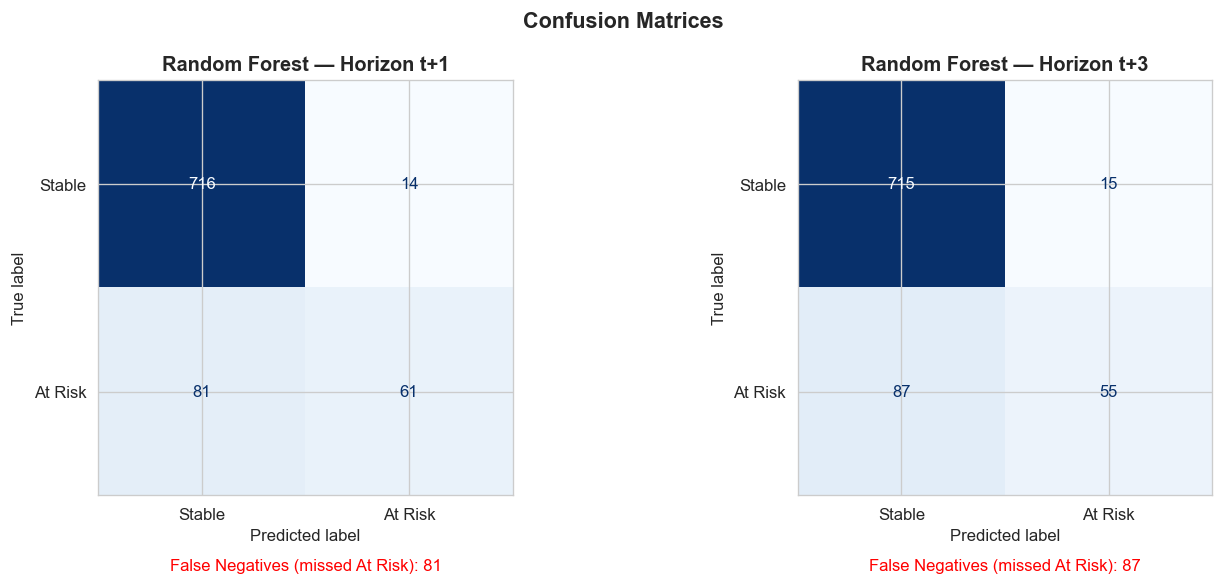

In [12]:
# Confusion matrices (Random Forest only)
rf_results = [r for r in results if r['Model'] == 'Random Forest']
fig, axes  = plt.subplots(1, 2, figsize=(12, 5))
for ax, r, y_te in zip(axes, rf_results, [y_test_b, y_test_c]):
    cm   = confusion_matrix(y_te, r['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Stable','At Risk'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Random Forest — Horizon {r["Horizon"]}', fontweight='bold')
    fn = cm[1, 0]
    ax.text(0.5, -0.18, f'False Negatives (missed At Risk): {fn}',
            ha='center', transform=ax.transAxes, color='red', fontsize=10)
plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/05_confusion_matrices.png', bbox_inches='tight')
plt.show()

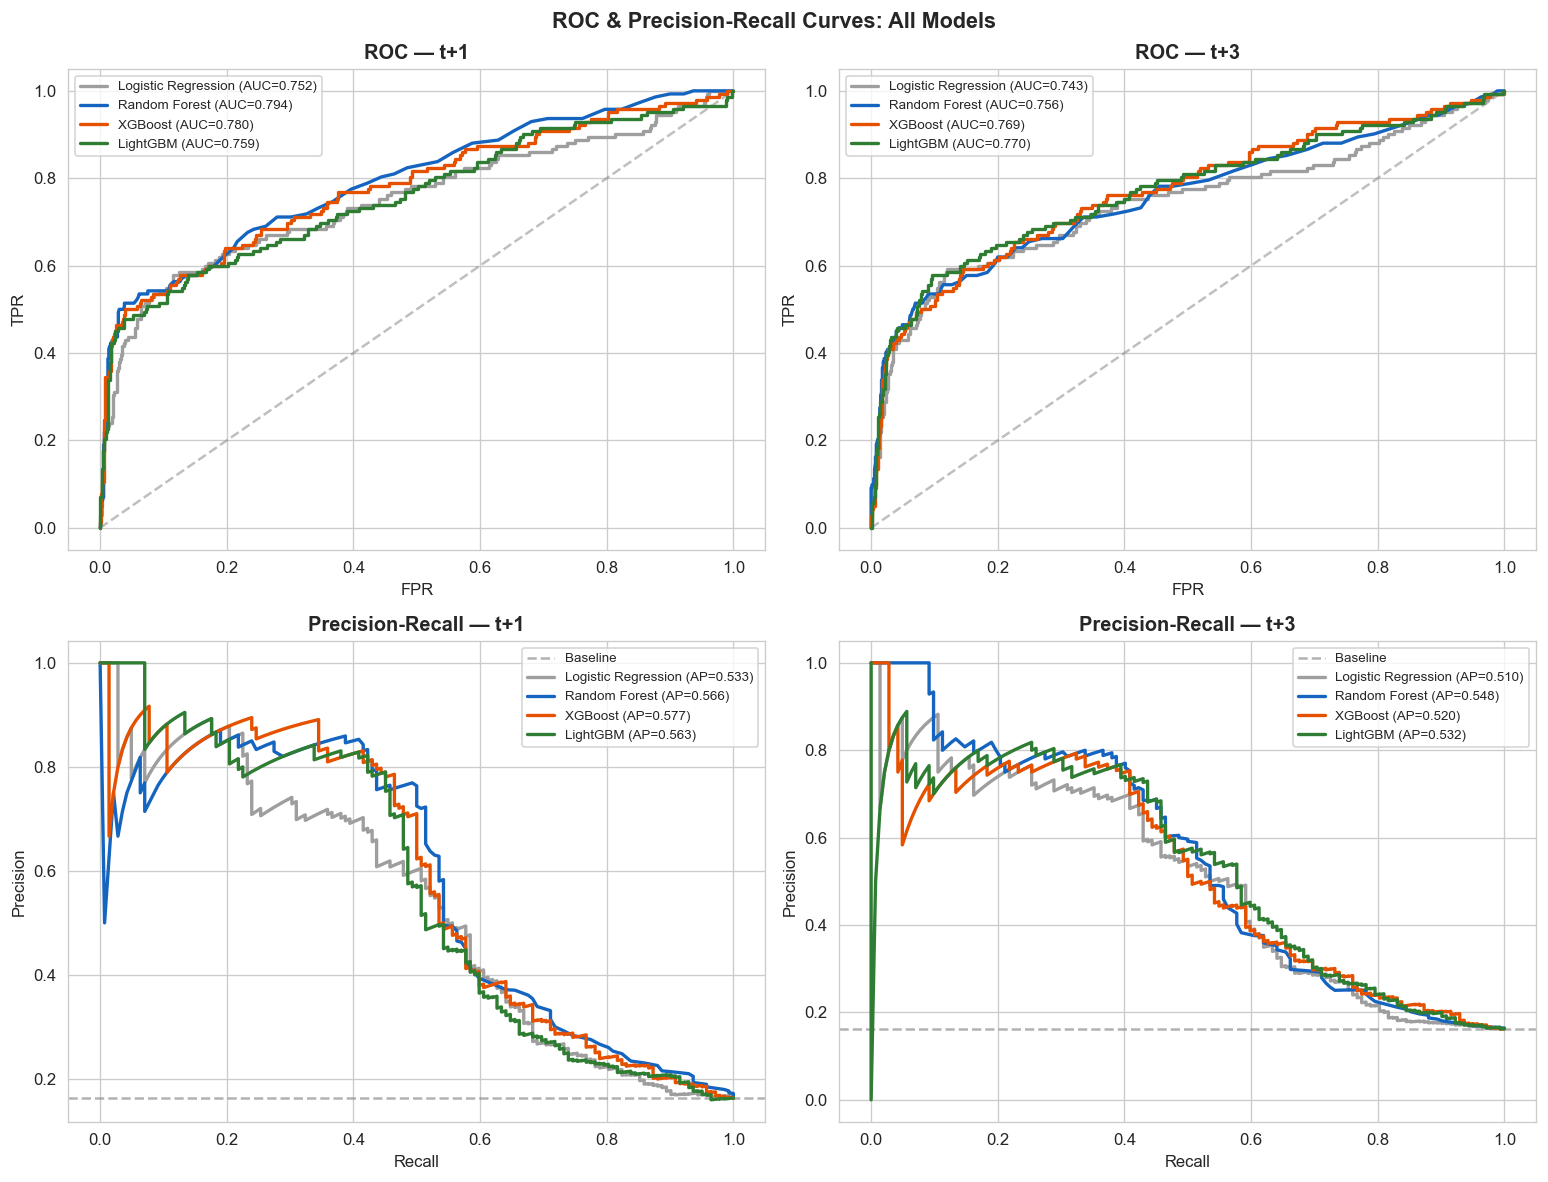

In [13]:
# ROC and Precision-Recall curves
CMAP = {'Logistic Regression':'#9E9E9E','Random Forest':'#1565C0',
        'XGBoost':'#E65100','LightGBM':'#2E7D32'}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for col_idx, (horizon, y_te) in enumerate(zip(['t+1','t+3'],[y_test_b,y_test_c])):
    # ROC
    ax_roc = axes[0][col_idx]
    ax_roc.plot([0,1],[0,1],'--',color='grey',alpha=0.5)
    for r in [x for x in results if x['Horizon']==horizon]:
        fpr, tpr, _ = roc_curve(y_te, r['y_prob'])
        ax_roc.plot(fpr, tpr, label=f'{r["Model"]} (AUC={r["AUC"]:.3f})',
                    color=CMAP[r['Model']], linewidth=2)
    ax_roc.set_title(f'ROC — {horizon}', fontweight='bold')
    ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
    ax_roc.legend(fontsize=8)

    # PR
    ax_pr = axes[1][col_idx]
    ax_pr.axhline(y_te.mean(), linestyle='--', color='grey', alpha=0.6, label='Baseline')
    for r in [x for x in results if x['Horizon']==horizon]:
        prec, rec, _ = precision_recall_curve(y_te, r['y_prob'])
        ax_pr.plot(rec, prec, label=f'{r["Model"]} (AP={r["AP"]:.3f})',
                   color=CMAP[r['Model']], linewidth=2)
    ax_pr.set_title(f'Precision-Recall — {horizon}', fontweight='bold')
    ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
    ax_pr.legend(fontsize=8)

plt.suptitle('ROC & Precision-Recall Curves: All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/06_roc_pr_curves.png', bbox_inches='tight')
plt.show()

In [14]:
# Full comparison table
metrics_df = pd.DataFrame([{
    'Model': r['Model'], 'Horizon': r['Horizon'],
    'Accuracy': r['Accuracy'], 'Recall@AtRisk': r['Recall'],
    'Precision@AtRisk': r['Precision'], 'F1@AtRisk': r['F1'],
    'ROC-AUC': r['AUC'], 'Avg-Precision': r['AP']
} for r in results])

print('\n=== FINAL MODEL COMPARISON TABLE ===')
print(metrics_df.to_string(index=False))
print('\nPrimary metric: Recall@AtRisk (minimise missed At Risk events)')
metrics_df.to_csv('models/model_metrics.csv', index=False)


=== FINAL MODEL COMPARISON TABLE ===
              Model Horizon  Accuracy  Recall@AtRisk  Precision@AtRisk  F1@AtRisk  ROC-AUC  Avg-Precision
Logistic Regression     t+1    0.8073         0.5845            0.4323     0.4970   0.7522         0.5335
Logistic Regression     t+3    0.7890         0.5986            0.4009     0.4802   0.7426         0.5101
      Random Forest     t+1    0.8911         0.4296            0.8133     0.5622   0.7941         0.5664
      Random Forest     t+3    0.8830         0.3873            0.7857     0.5189   0.7556         0.5479
            XGBoost     t+1    0.8911         0.4577            0.7831     0.5778   0.7796         0.5773
            XGBoost     t+3    0.8704         0.4366            0.6526     0.5232   0.7689         0.5205
           LightGBM     t+1    0.8819         0.4577            0.7143     0.5579   0.7594         0.5634
           LightGBM     t+3    0.8658         0.4648            0.6168     0.5301   0.7702         0.5320

Primary

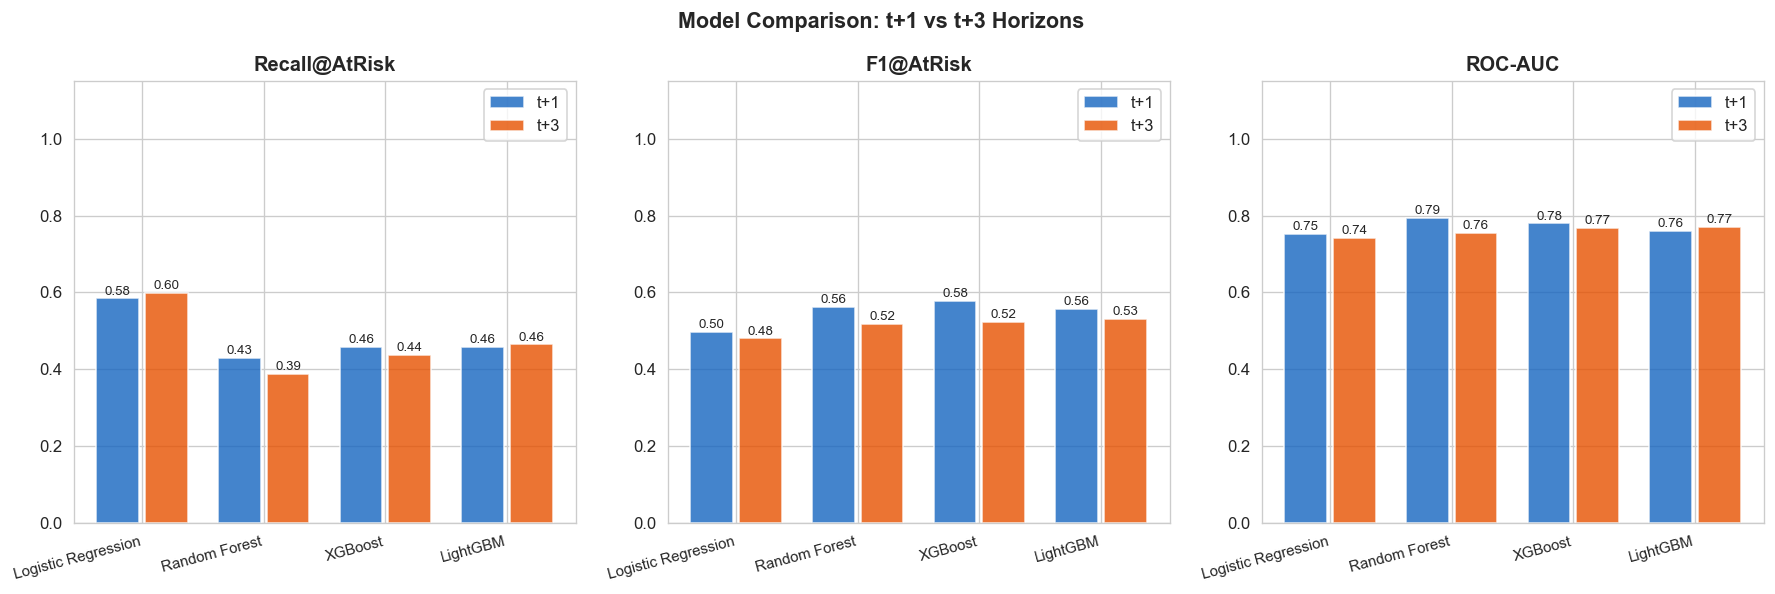

In [15]:
# Bar chart comparison
model_order  = ['Logistic Regression','Random Forest','XGBoost','LightGBM']
metric_list  = ['Recall@AtRisk','F1@AtRisk','ROC-AUC']
fig, axes    = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, metric_list):
    x = np.arange(len(model_order))
    for i, (hz, color) in enumerate(zip(['t+1','t+3'],['#1565C0','#E65100'])):
        sub  = metrics_df[metrics_df['Horizon']==hz]
        vals = [sub[sub['Model']==m][metric].values[0] for m in model_order]
        bars = ax.bar(x + (-0.2 + 0.4*i), vals, width=0.35, color=color, alpha=0.8, label=hz)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f'{v:.2f}', ha='center', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(model_order, rotation=15, ha='right', fontsize=9)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.legend()

plt.suptitle('Model Comparison: t+1 vs t+3 Horizons', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/07_model_comparison.png', bbox_inches='tight')
plt.show()

## 10. Threshold Tuning

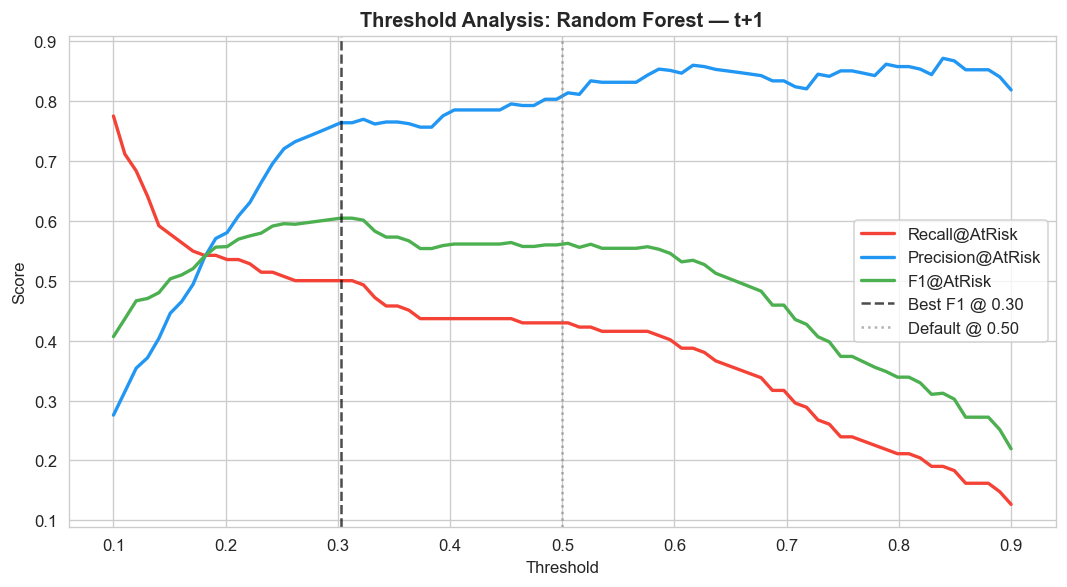

Optimal threshold (t+1): 0.30
Results at threshold 0.30:
              precision    recall  f1-score   support

      Stable      0.909     0.970     0.938       730
     At Risk      0.763     0.500     0.604       142

    accuracy                          0.893       872
   macro avg      0.836     0.735     0.771       872
weighted avg      0.885     0.893     0.884       872



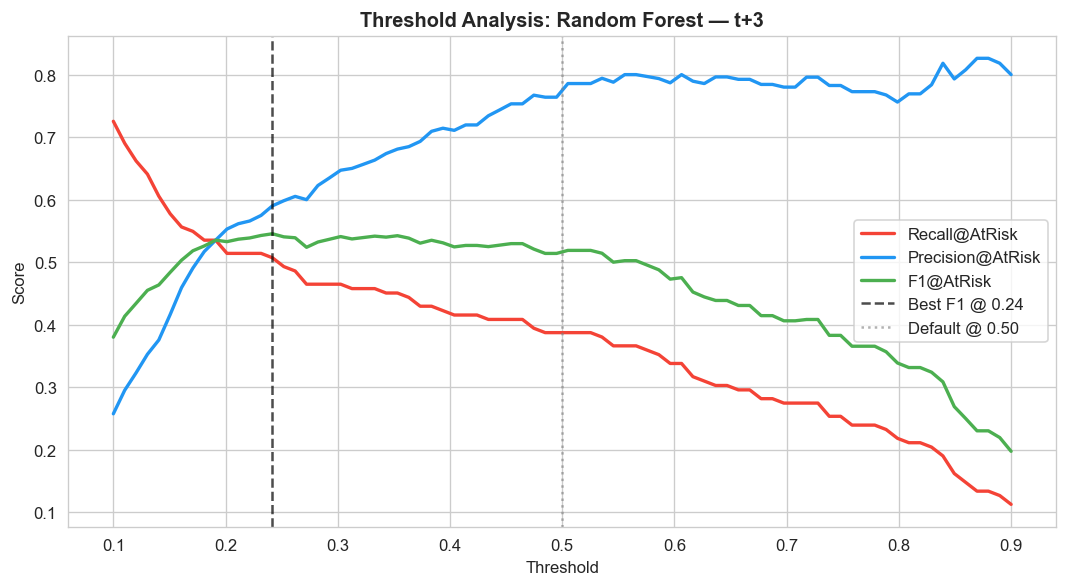

Optimal threshold (t+3): 0.24
Results at threshold 0.24:
              precision    recall  f1-score   support

      Stable      0.907     0.932     0.919       730
     At Risk      0.590     0.507     0.545       142

    accuracy                          0.862       872
   macro avg      0.748     0.719     0.732       872
weighted avg      0.855     0.862     0.858       872



In [16]:
def tune_threshold(y_true, y_prob, name, horizon):
    thresholds = np.linspace(0.1, 0.9, 80)
    recalls, precisions, f1s = [], [], []
    for t in thresholds:
        yp = (y_prob >= t).astype(int)
        recalls.append(recall_score(y_true, yp, pos_label=1, zero_division=0))
        precisions.append(precision_score(y_true, yp, pos_label=1, zero_division=0))
        f1s.append(f1_score(y_true, yp, pos_label=1, zero_division=0))
    best_t = thresholds[np.argmax(f1s)]
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(thresholds, recalls,    color='#F44336', linewidth=2, label='Recall@AtRisk')
    ax.plot(thresholds, precisions, color='#2196F3', linewidth=2, label='Precision@AtRisk')
    ax.plot(thresholds, f1s,        color='#4CAF50', linewidth=2, label='F1@AtRisk')
    ax.axvline(best_t, linestyle='--', color='black', alpha=0.7, label=f'Best F1 @ {best_t:.2f}')
    ax.axvline(0.5,    linestyle=':',  color='grey',  alpha=0.6, label='Default @ 0.50')
    ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
    ax.set_title(f'Threshold Analysis: {name} — {horizon}', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'plots/08_threshold_{horizon}.png', bbox_inches='tight')
    plt.show()
    print(f'Optimal threshold ({horizon}): {best_t:.2f}')

    # Re-evaluate with best threshold
    yp_opt = (y_prob >= best_t).astype(int)
    print(f'Results at threshold {best_t:.2f}:')
    print(classification_report(y_true, yp_opt, target_names=['Stable','At Risk'], digits=3))
    return best_t

rf_b_res = [r for r in results if r['Model']=='Random Forest' and r['Horizon']=='t+1'][0]
rf_c_res = [r for r in results if r['Model']=='Random Forest' and r['Horizon']=='t+3'][0]

best_t_b = tune_threshold(y_test_b, rf_b_res['y_prob'], 'Random Forest', 't+1')
best_t_c = tune_threshold(y_test_c, rf_c_res['y_prob'], 'Random Forest', 't+3')

## 11. Interpretability — Feature Importance & SHAP

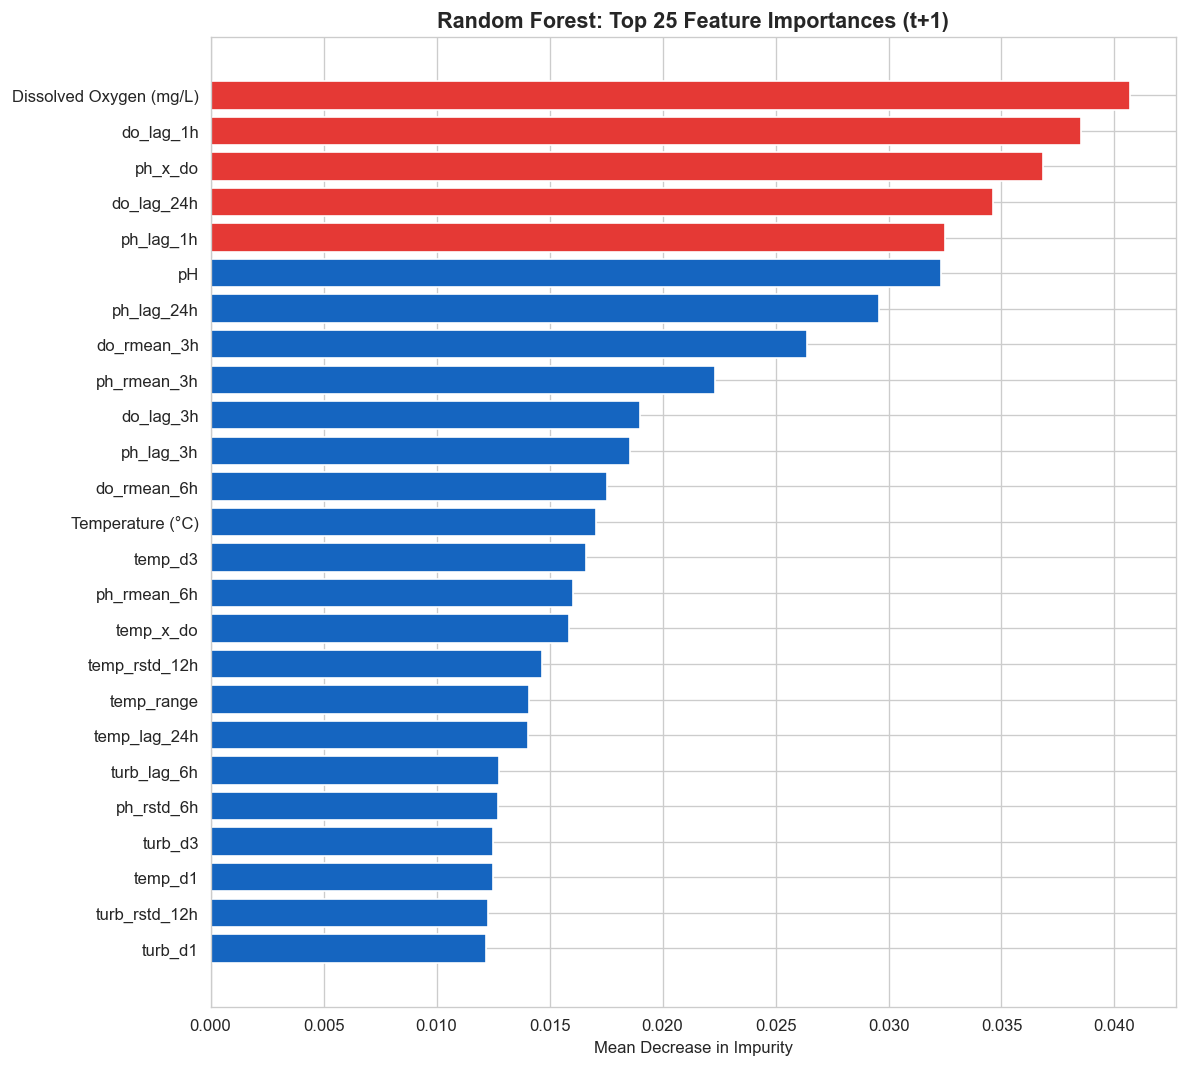

In [17]:
# Feature importance — Random Forest Model B
importances = rf_b_res['model_obj'].feature_importances_
fi_df = pd.DataFrame({'Feature': FEAT_COLS, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True).tail(25)

fig, ax = plt.subplots(figsize=(10, 9))
bar_colors = ['#E53935' if v > fi_df['Importance'].quantile(0.8) else '#1565C0'
              for v in fi_df['Importance']]
ax.barh(fi_df['Feature'], fi_df['Importance'], color=bar_colors)
ax.set_title('Random Forest: Top 25 Feature Importances (t+1)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.savefig('plots/09_feature_importance.png', bbox_inches='tight')
plt.show()

Computing SHAP values...


<Figure size 1320x1080 with 0 Axes>

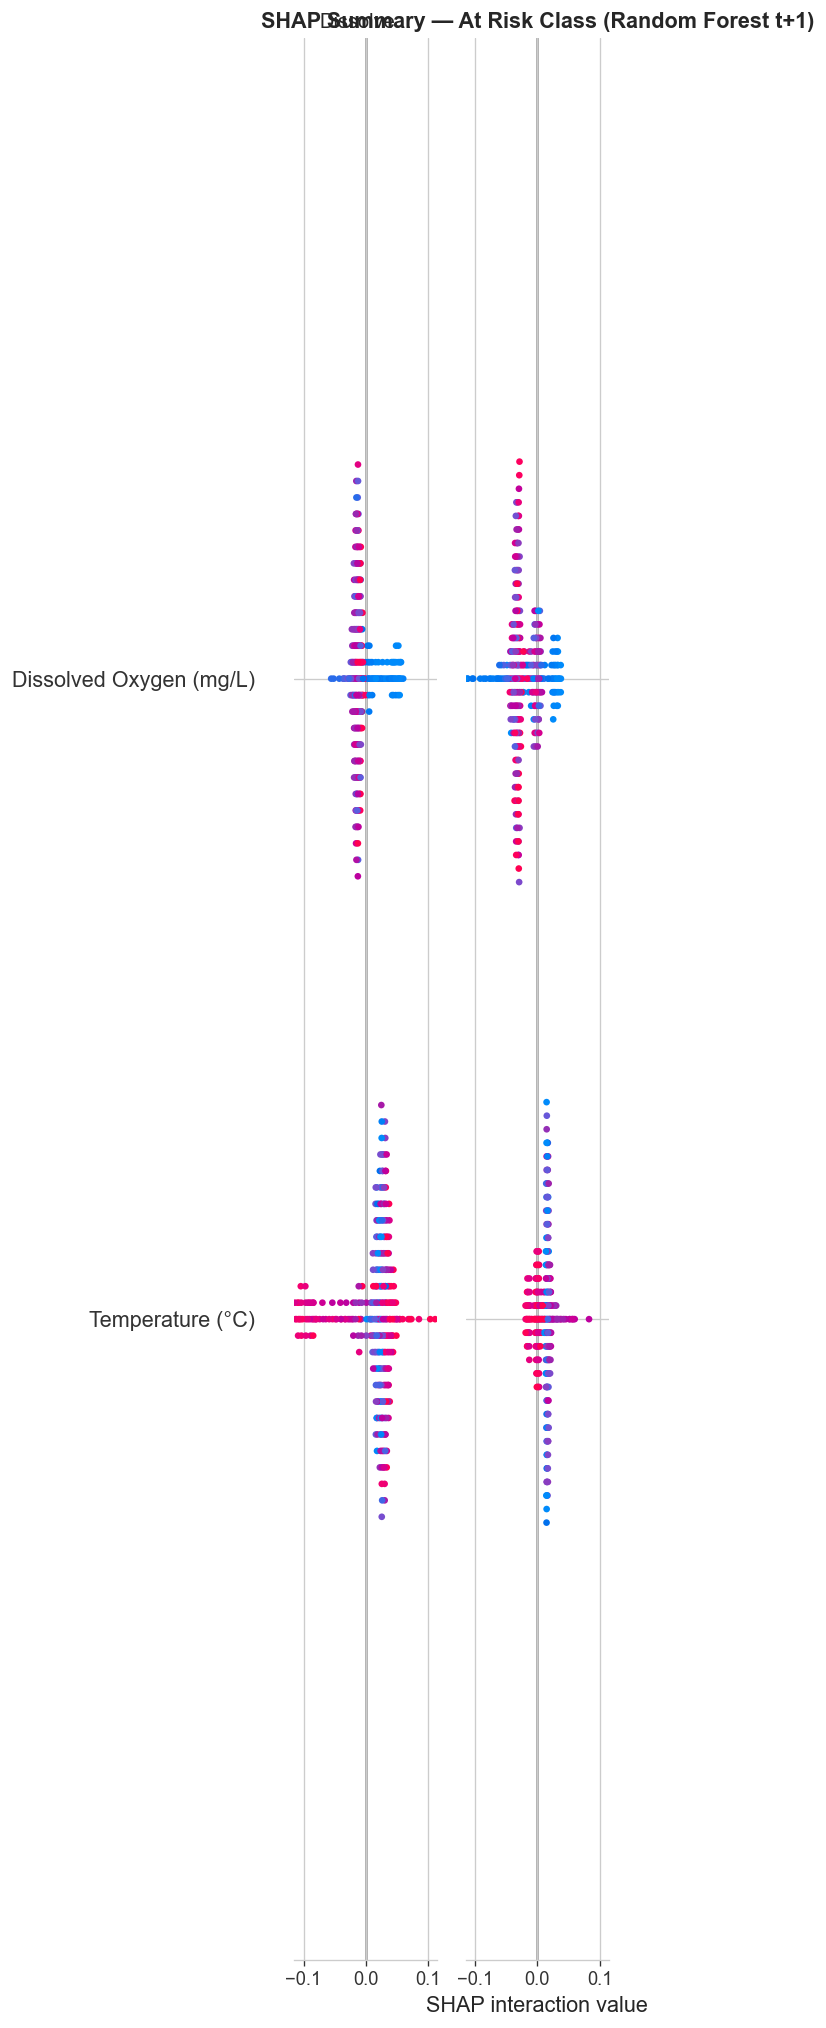

Done.


In [18]:
# SHAP values
print('Computing SHAP values...')
np.random.seed(RANDOM_STATE)
shap_idx = np.random.choice(len(X_test_b), size=min(300, len(X_test_b)), replace=False)
X_shap   = X_test_b[shap_idx]

explainer   = shap.TreeExplainer(rf_b_res['model_obj'])
shap_values = explainer.shap_values(X_shap)
shap_atrisk = shap_values[1] if isinstance(shap_values, list) else shap_values

plt.figure(figsize=(11, 9))
shap.summary_plot(shap_atrisk, X_shap, feature_names=FEAT_COLS,
                  max_display=20, show=False, plot_type='dot')
plt.title('SHAP Summary — At Risk Class (Random Forest t+1)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/10_shap_summary.png', bbox_inches='tight')
plt.show()
print('Done.')

<Figure size 1200x840 with 0 Axes>

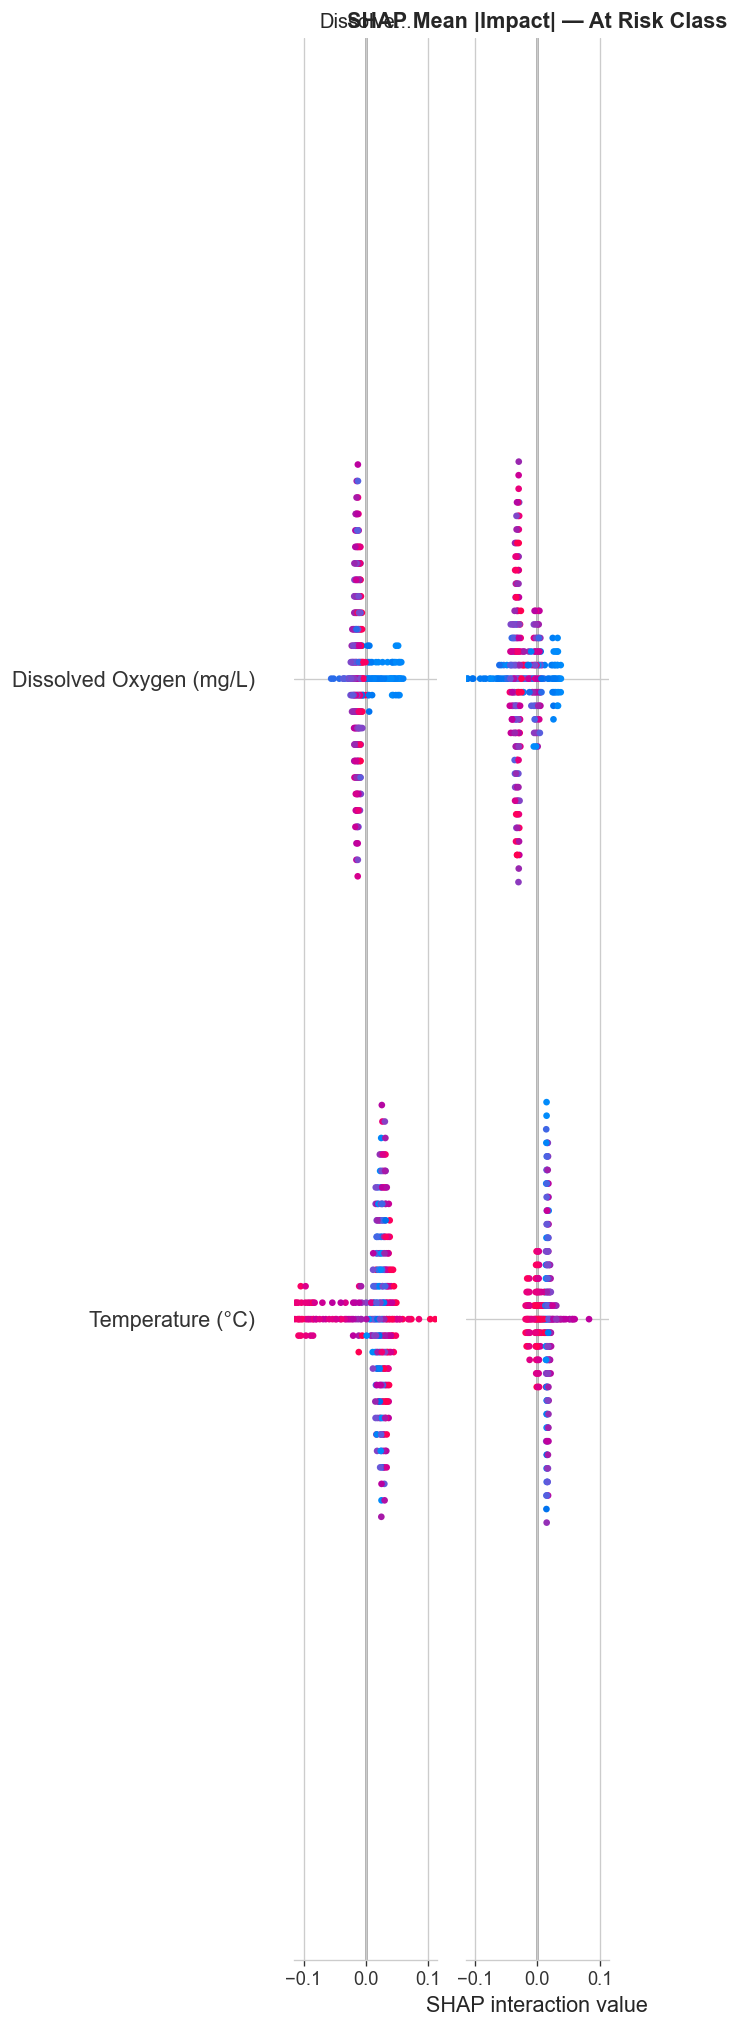

In [19]:
# SHAP bar plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_atrisk, X_shap, feature_names=FEAT_COLS,
                  max_display=20, show=False, plot_type='bar')
plt.title('SHAP Mean |Impact| — At Risk Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/11_shap_bar.png', bbox_inches='tight')
plt.show()

## 12. Save Models for Streamlit Deployment

In [20]:
rf_b_model  = rf_b_res['model_obj']
rf_c_model  = rf_c_res['model_obj']
xgb_b_model = [r['model_obj'] for r in results if r['Model']=='XGBoost'  and r['Horizon']=='t+1'][0]
xgb_c_model = [r['model_obj'] for r in results if r['Model']=='XGBoost'  and r['Horizon']=='t+3'][0]
lgb_b_model = [r['model_obj'] for r in results if r['Model']=='LightGBM' and r['Horizon']=='t+1'][0]
lgb_c_model = [r['model_obj'] for r in results if r['Model']=='LightGBM' and r['Horizon']=='t+3'][0]

artifacts = {
    'rf_model_t1':   rf_b_model,
    'rf_model_t3':   rf_c_model,
    'xgb_model_t1':  xgb_b_model,
    'xgb_model_t3':  xgb_c_model,
    'lgbm_model_t1': lgb_b_model,
    'lgbm_model_t3': lgb_c_model,
    'scaler':        scaler,
    'feature_cols':  FEAT_COLS,
    'threshold_t1':  best_t_b,
    'threshold_t3':  best_t_c,
}

for name, obj in artifacts.items():
    path = f'models/{name}.pkl'
    joblib.dump(obj, path)
    print(f'Saved: {path}')

print('\n=== FINAL RESULTS ===')
print(metrics_df[['Model','Horizon','Accuracy','Recall@AtRisk','F1@AtRisk','ROC-AUC']].to_string(index=False))
print('\nAll models and artifacts saved in models/')

Saved: models/rf_model_t1.pkl
Saved: models/rf_model_t3.pkl
Saved: models/xgb_model_t1.pkl
Saved: models/xgb_model_t3.pkl
Saved: models/lgbm_model_t1.pkl
Saved: models/lgbm_model_t3.pkl
Saved: models/scaler.pkl
Saved: models/feature_cols.pkl
Saved: models/threshold_t1.pkl
Saved: models/threshold_t3.pkl

=== FINAL RESULTS ===
              Model Horizon  Accuracy  Recall@AtRisk  F1@AtRisk  ROC-AUC
Logistic Regression     t+1    0.8073         0.5845     0.4970   0.7522
Logistic Regression     t+3    0.7890         0.5986     0.4802   0.7426
      Random Forest     t+1    0.8911         0.4296     0.5622   0.7941
      Random Forest     t+3    0.8830         0.3873     0.5189   0.7556
            XGBoost     t+1    0.8911         0.4577     0.5778   0.7796
            XGBoost     t+3    0.8704         0.4366     0.5232   0.7689
           LightGBM     t+1    0.8819         0.4577     0.5579   0.7594
           LightGBM     t+3    0.8658         0.4648     0.5301   0.7702

All models and 

---
## Summary of Results

| What changed | Why |
|---|---|
| Removed 19 leaky/synthetic columns | They encoded the answer directly |
| Rebuilt dataset with real hourly dynamics | Original had static values for 24h blocks |
| Multi-parameter stress target | No single sensor perfectly separates classes |
| No SMOTE | Lag features break temporal integrity; class_weight is safer |
| Accuracy is NOT the primary metric | 84% baseline just by predicting Stable always |
| Threshold tuning | Optimises Recall@AtRisk for real early-warning use |

### Limitation Note
Ammonia concentration (mentioned in abstract) is absent from the dataset — acknowledge as a limitation and future direction.